In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# Base paths
TRAIN_IMAGES = "/teamspace/studios/this_studio/cell_dataset/train/train_images"
TRAIN_MASKS  = "/teamspace/studios/this_studio/cell_dataset/train/train_masks"
TEST_IMAGES  = "/teamspace/studios/this_studio/cell_dataset/test/test_images"

print("✅ Imports done!")

✅ Imports done!


In [ ]:
# List first 5 files in each folder to understand naming format
train_images = sorted(os.listdir(TRAIN_IMAGES))
train_masks  = sorted(os.listdir(TRAIN_MASKS))
test_images  = sorted(os.listdir(TEST_IMAGES))

print(f"Train images: {len(train_images)}")
print(f"Train masks:  {len(train_masks)}")
print(f"Test images:  {len(test_images)}")

print(f"\nSample image names: {train_images[:5]}")
print(f"Sample mask names:  {train_masks[:5]}")

FileNotFoundError: [Errno 2] No such file or directory: '/teamspace/studios/this_studio/cell_dataset/train/train_images'

In [3]:
# Scan all 108 masks to find every unique color used across the entire dataset
all_colors = set()

for mask_name in train_masks:
    mask = np.array(Image.open(os.path.join(TRAIN_MASKS, mask_name)))
    unique = np.unique(mask.reshape(-1, 3), axis=0)
    for color in unique:
        all_colors.add(tuple(color))

print(f"All unique colors found across all 108 masks:")
for color in sorted(all_colors):
    print(f"  {color}")

NameError: name 'train_masks' is not defined

NameError: name 'train_images' is not defined

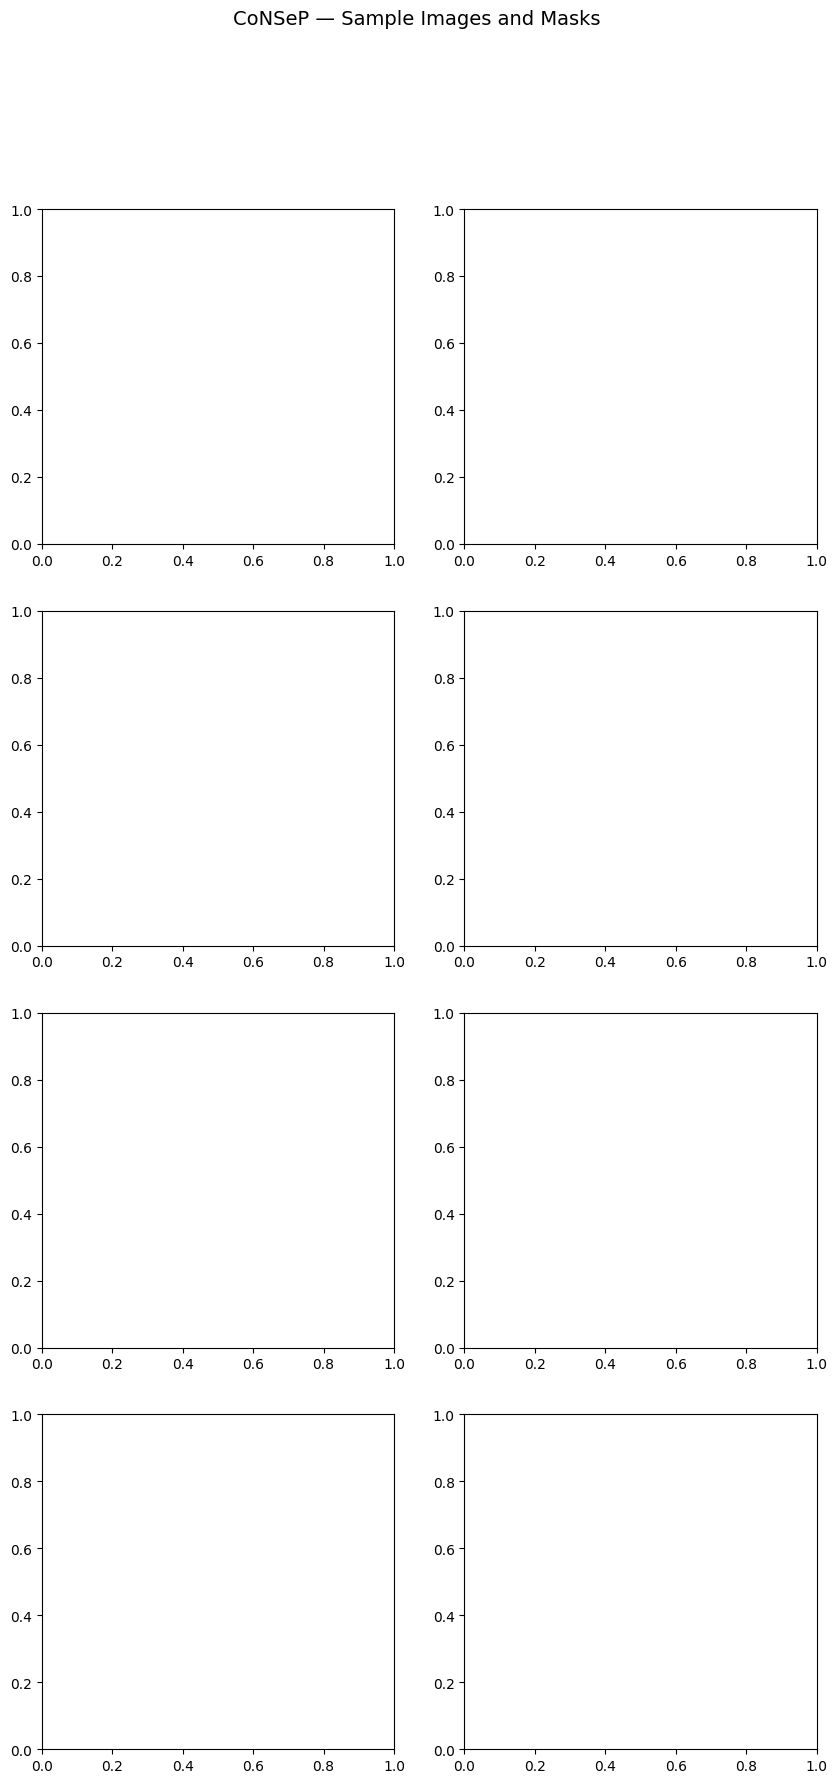

In [4]:
# Display 4 sample image-mask pairs to understand what we're segmenting
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
fig.suptitle("CoNSeP — Sample Images and Masks", fontsize=14)

for i in range(4):
    img  = Image.open(os.path.join(TRAIN_IMAGES, train_images[i]))
    mask = Image.open(os.path.join(TRAIN_MASKS,  train_masks[i]))

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image: {train_images[i]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask)
    axes[i, 1].set_title(f"Mask: {train_masks[i]}", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/sample_pairs.png", dpi=150)
plt.show()
print("✅ Saved to ../results/sample_pairs.png")

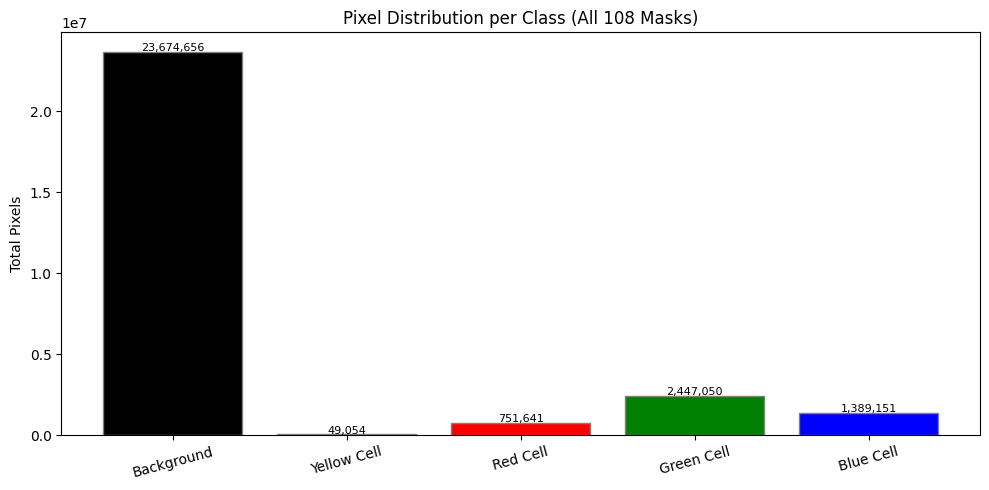


Pixel counts per class:
  Background      →   23,674,656 pixels (83.6%)
  Yellow Cell     →       49,054 pixels (0.2%)
  Red Cell        →      751,641 pixels (2.7%)
  Green Cell      →    2,447,050 pixels (8.6%)
  Blue Cell       →    1,389,151 pixels (4.9%)


In [6]:
# Define the 5 classes with their RGB colors
CLASS_COLORS = {
    "Background":  (0,   0,   0),
    "Yellow Cell": (255, 255, 0),
    "Red Cell":    (255, 0,   0),
    "Green Cell":  (0,   255, 0),
    "Blue Cell":   (0,   0,   255),
}

# Count pixels per class across all masks
pixel_counts = {name: 0 for name in CLASS_COLORS}

for mask_name in train_masks:
    mask = np.array(Image.open(os.path.join(TRAIN_MASKS, mask_name)))
    for class_name, color in CLASS_COLORS.items():
        match = np.all(mask == np.array(color), axis=-1)
        pixel_counts[class_name] += match.sum()

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(pixel_counts.keys(), pixel_counts.values(),
               color=["black", "yellow", "red", "green", "blue"],
               edgecolor="gray")
plt.title("Pixel Distribution per Class (All 108 Masks)")
plt.ylabel("Total Pixels")
plt.xticks(rotation=15)

for bar, count in zip(bars, pixel_counts.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50000,
             f"{count:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../results/class_distribution.png", dpi=150)
plt.show()

print("\nPixel counts per class:")
total = sum(pixel_counts.values())
for name, count in pixel_counts.items():
    print(f"  {name:<15} → {count:>12,} pixels ({count/total*100:.1f}%)")

In [5]:
print("DATASET EXPLORATION COMPLETE")
print(f"  Train images:      108 (512x512 RGB)")
print(f"  Train masks:       108 (512x512 RGB)")
print(f"  Test images:       56")
print(f"  Classes:           5")
print(f"  Class imbalance:   SEVERE (Yellow = 0.2%)")
print(f"  Mask format:       RGB color → class ID")
print()
print("  Class mapping:")
print("    0 → Background  (0,   0,   0)  — 83.6%")
print("    1 → Yellow Cell (255, 255, 0)  —  0.2%")
print("    2 → Red Cell    (255, 0,   0)  —  2.7%")
print("    3 → Green Cell  (0,   255, 0)  —  8.6%")
print("    4 → Blue Cell   (0,   0,   255)—  4.9%")
print()
print("  Key challenge: Class imbalance")
print("  Solution: Dice Loss + Weighted Cross Entropy")


DATASET EXPLORATION COMPLETE
  Train images:      108 (512x512 RGB)
  Train masks:       108 (512x512 RGB)
  Test images:       56
  Classes:           5
  Class imbalance:   SEVERE (Yellow = 0.2%)
  Mask format:       RGB color → class ID

  Class mapping:
    0 → Background  (0,   0,   0)  — 83.6%
    1 → Yellow Cell (255, 255, 0)  —  0.2%
    2 → Red Cell    (255, 0,   0)  —  2.7%
    3 → Green Cell  (0,   255, 0)  —  8.6%
    4 → Blue Cell   (0,   0,   255)—  4.9%

  Key challenge: Class imbalance
  Solution: Dice Loss + Weighted Cross Entropy
